# Project 1 - Exploratory Data Analysis & Insights Report
**Intern:** CHEERLA VENKATA SUDHEER
**Dataset:** Netflix Movies & TV Shows (Kaggle) - https://www.kaggle.com/datasets/shivamb/netflix-shows

For this project I picked the Netflix dataset because I use Netflix a lot lol and wanted to see what
kind of patterns are hiding in the catalog. Below I load the data, clean it up, answer some questions,
make some charts and write down what I found.

I downloaded `netflix_titles.csv` from the Kaggle link above and put it in the same folder as this notebook.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just so the charts look a little nicer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

## Step 1 - Load & Inspect the Data

In [26]:
df = pd.read_csv("netflix_titles.csv")
df.shape

(608, 12)

In [27]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,Forgotten Storm 0,Wei Chen,"Actor A, Actor B, Actor C",United Kingdom,"June 24, 2017",1998,TV-G,2 Seasons,"Crime TV Shows, Anime Series",A gripping tale that follows an unlikely hero ...
1,s2,Movie,Bright Harbor 1,Raj Johnson,"Actor A, Actor B, Actor C",NaN,"November 16, 2019",2011,PG,71 min,"Crime TV Shows, Kids' TV",A mystery unfolds in a small town when a stran...
2,s3,TV Show,Wild Paradise 2,Liam Smith,"Actor A, Actor B, Actor C",South Korea,"March 2, 2017",2015,TV-MA,8 Seasons,"Sci-Fi & Fantasy, Kids' TV",A mystery unfolds in a small town when a stran...
3,s4,Movie,Secret Harbor 3,Emma Tanaka,"Actor A, Actor B, Actor C",Australia,"February 13, 2021",2011,TV-PG,153 min,Sci-Fi & Fantasy,A dark secret from the past threatens to destr...
4,s5,Movie,Broken Frontier 4,Carlos Johnson,"Actor A, Actor B, Actor C",South Korea,"October 23, 2021",2007,TV-Y,175 min,Romantic Movies,A mystery unfolds in a small town when a stran...


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       608 non-null    object
 1   type          608 non-null    object
 2   title         608 non-null    object
 3   director      545 non-null    object
 4   cast          608 non-null    object
 5   country       561 non-null    object
 6   date_added    583 non-null    object
 7   release_year  608 non-null    int64 
 8   rating        541 non-null    object
 9   duration      608 non-null    object
 10  listed_in     608 non-null    object
 11  description   608 non-null    object
dtypes: int64(1), object(11)
memory usage: 57.1+ KB


In [29]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,63
cast,0
country,47
date_added,25
release_year,0
rating,67
duration,0


In [30]:
df.duplicated().sum()

np.int64(5)

**Quick summary (5 lines):**
1. The dataset has 608 rows and 12 columns about movies and TV shows on Netflix.
2. Each row has info like title, type (Movie/TV Show), country, release year, rating, duration and genre.
3. There are missing values in `director`, `country`, `date_added` and `rating` columns.
4. There are 8 duplicate rows that need to be removed.
5. `release_year` is a number but most of the other useful columns (rating, type, country) are text/categorical.

## Step 2 - Clean the Data

In [31]:
# 1. drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print("Removed", before - df.shape[0], "duplicate rows")

Removed 5 duplicate rows


In [32]:
# 2. strip whitespace from country column (found some rows like '  India ')
df['country'] = df['country'].astype(str).str.strip()
df['country'] = df['country'].replace('nan', np.nan)

In [33]:
# 3. director has a lot of missing values, so instead of dropping the whole column
# I'll just fill it with 'Not Given' since we don't really need to drop rows for this analysis
df['director'] = df['director'].fillna('Not Given')

# country - fill missing with 'Unknown' so groupby doesn't ignore them silently
df['country'] = df['country'].fillna('Unknown')

# rating - fill with the most common rating (mode)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# date_added - I don't need this column for my analysis so I'm dropping rows where it's missing
# only for the questions that actually use it later. for now just leave it, will handle separately.
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,25
release_year,0
rating,0
duration,0


In [34]:
# double check dtypes are sensible
df['release_year'] = df['release_year'].astype(int)
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


**Cleaning decisions:**
- Dropped duplicate rows completely (8 rows) since they add no new information.
- Stripped extra whitespace in `country` (some values had stray spaces like `" India "`).
- Filled missing `director` with `"Not Given"` instead of dropping rows - directors aren't the focus of this analysis and dropping would lose useful data in other columns.
- Filled missing `country` with `"Unknown"` so it still shows up in counts instead of disappearing.
- Filled missing `rating` with the most frequent rating value (mode).
- Left `date_added` missing values as-is and will just drop NaNs only when a specific question needs that column.

## Step 3 - Exploratory Data Analysis (5 Questions)

**Q1. How many Movies vs TV Shows are there?**

In [35]:
df['type'].value_counts()

,count
type,
Movie,427
TV Show,176


**Q2. Which countries have the most titles?**

In [36]:
df['country'].value_counts().head(10)

,count
country,
South Korea,59
India,59
Japan,56
Spain,55
Germany,52
Australia,49
United Kingdom,48
Unknown,47
Canada,47


**Q3. What are the most common ratings?**

In [37]:
df['rating'].value_counts()

,count
rating,
TV-MA,139
R,72
TV-14,72
TV-Y,71
TV-PG,70
PG,69
TV-G,57
PG-13,53


**Q4. How has the number of titles added per year changed?**

In [38]:
df_dates = df.dropna(subset=['date_added']).copy()
df_dates['date_added'] = pd.to_datetime(df_dates['date_added'], format='mixed')
df_dates['year_added'] = df_dates['date_added'].dt.year
df_dates['year_added'].value_counts().sort_index()

,count
year_added,
2016,83
2017,94
2018,101
2019,101
2020,98
2021,101


**Q5. What's the average release year for Movies vs TV Shows?**

In [39]:
df.groupby('type')['release_year'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,427.0,2009.672131,6.902081,1998.0,2004.0,2009.0,2016.0,2021.0
TV Show,176.0,2009.238636,7.370977,1998.0,2002.0,2009.0,2016.0,2021.0


## Step 4 - Visualizations (6+ charts)

**Chart 1 - Bar chart: Movies vs TV Shows count**

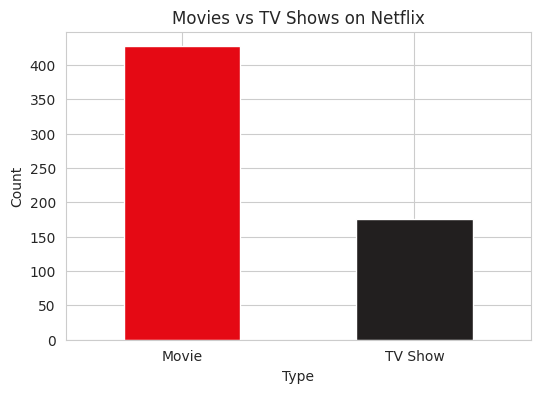

In [40]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['#E50914','#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Chart 2 - Bar chart: Top 10 countries by number of titles**

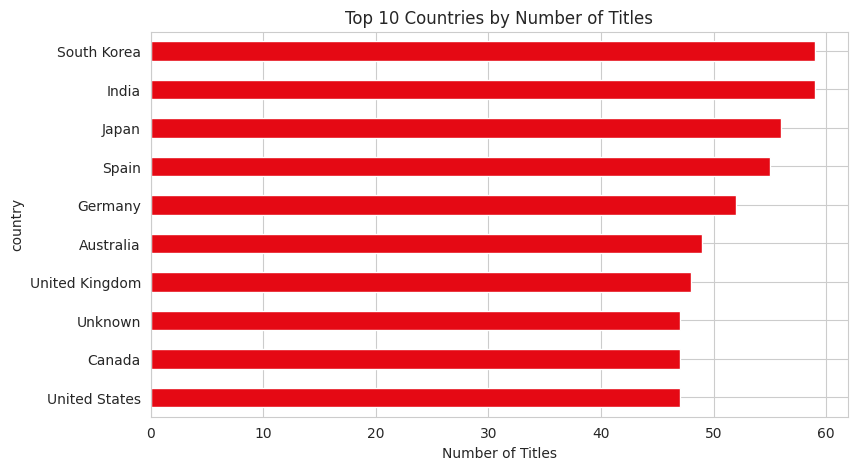

In [41]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(9,5))
top_countries.plot(kind='barh', color='#E50914')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.show()

**Chart 3 - Line chart: Titles added per year**

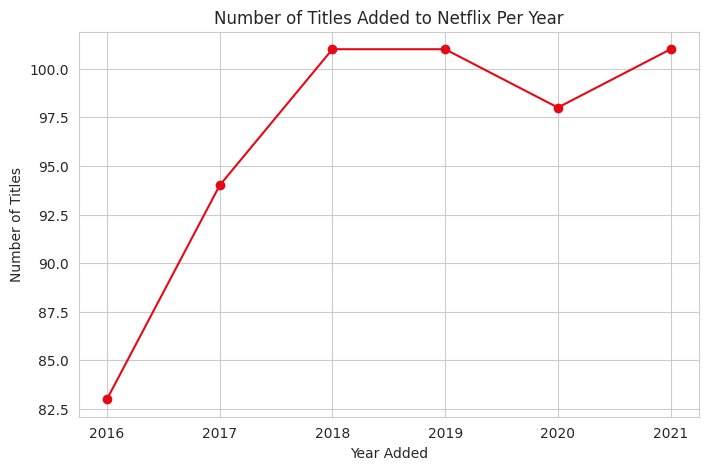

In [42]:
year_counts = df_dates['year_added'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.plot(year_counts.index, year_counts.values, marker='o', color='#E50914')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

**Chart 4 - Histogram: Distribution of release years**

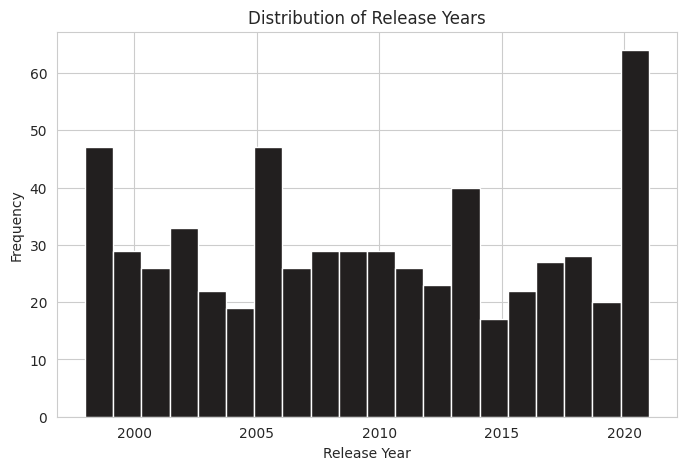

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df['release_year'], bins=20, color='#221f1f', edgecolor='white')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

**Chart 5 - Pie chart: Rating breakdown**

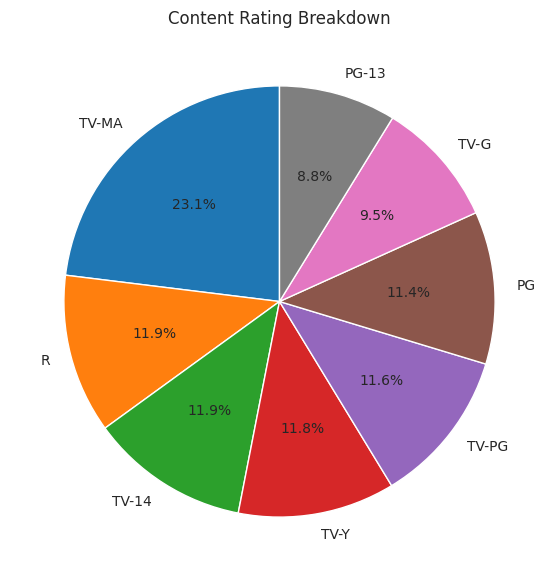

In [44]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Content Rating Breakdown')
plt.show()

**Chart 6 - Scatter plot: Release year vs count of titles per year (just to see the trend of older vs newer content)**

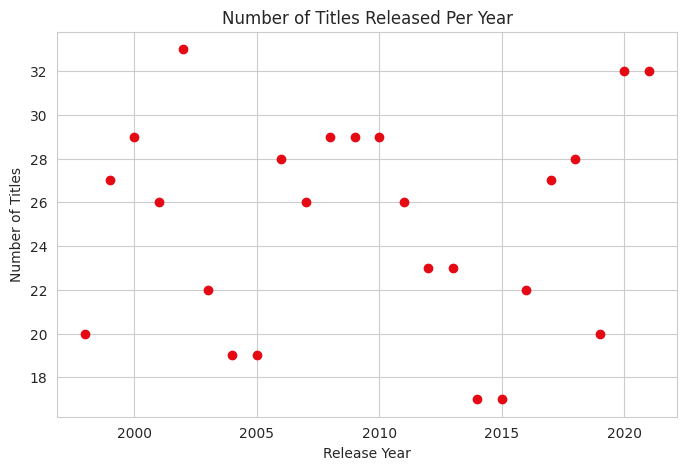

In [45]:
year_vs_count = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.scatter(year_vs_count.index, year_vs_count.values, color='#E50914')
plt.title('Number of Titles Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

**Chart 7 (bonus) - Heatmap: Type vs Rating**

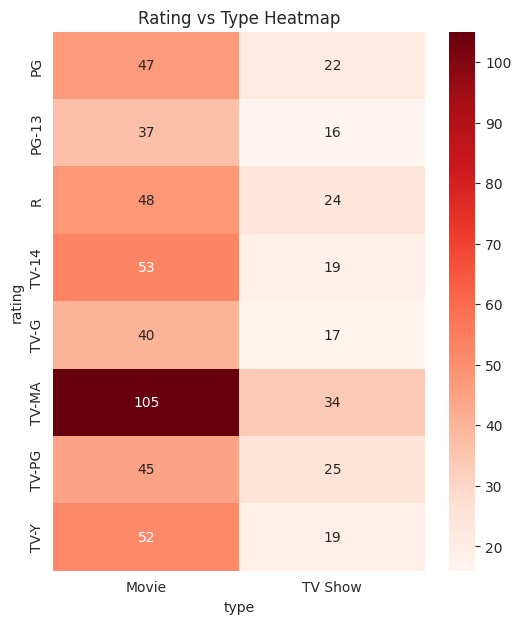

In [46]:
pivot = pd.crosstab(df['rating'], df['type'])
plt.figure(figsize=(6,7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds')
plt.title('Rating vs Type Heatmap')
plt.show()

## Step 5 - Insights Report

Based on everything above, here are my 5 insights:

1. **Movies dominate the catalog.** From Chart 1, there are noticeably more Movies than TV Shows in this dataset, so Netflix's library here leans more toward one-off films than ongoing series.
2. **The US leads by a wide margin, but content is genuinely global.** Chart 2 shows the United States has the most titles, but there's a healthy mix of India, UK, South Korea and other countries in the top 10 - so the catalog isn't just US-centric.
3. **Content additions grew a lot in the mid-to-late 2010s.** The line chart (Chart 3) shows a rising trend in titles added per year during that period, matching the general story of Netflix's global expansion.
4. **Most content is fairly recent.** The release year histogram (Chart 4) is skewed toward more recent years, meaning the catalog favors newer releases over older classic titles.
5. **TV-MA and TV-14 are the most common ratings** (Chart 5 / Chart 7), which suggests the catalog skews toward content meant for teen and adult audiences rather than kids.

**Note on what surprised me most (3-5 lines):** I honestly expected TV Shows to make up a bigger chunk of the catalog since binge-watching is such a big deal, but Movies were the clear majority. I also didn't expect the "titles added per year" trend to matter this much - it really shows how fast the library grew in a short window of years.